# Next-Word Prediction: GRU

Trains the GRU model on the prepared windows and evaluates it on the held-out test sentences.

Architecture (from the design sketch): `Embedding` -> `GRU` -> `Dropout` -> `Dense` (linear layer) with `softmax` -> a probability for every word -> the top 5 become the suggestions.

The GRU merges the cell and hidden state and uses two gates (update and reset), so it has fewer parameters than the LSTM and usually trains faster.

Metrics: **top-1** and **top-5 accuracy** (is the true next word the first guess / among the five suggestions) and **perplexity** = `exp(cross-entropy)`; lower perplexity means the model is less surprised by the real next word.

## 1. Setup

In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))  # so `import config` and `from src...` work from notebooks/

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import config
from src.dataset import load_corpus, prepare_data
from src.preprocess import Vocabulary, clean_text, split_sentences, tokenize

np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print("TensorFlow:", tf.__version__)
print("Corpus:", config.DEFAULT_CORPUS)
print("Outputs:", config.OUTPUTS_DIR)

TensorFlow: 2.21.0
Corpus: D:\next-word-prediction\data\raw\corpus.txt
Outputs: D:\next-word-prediction\outputs


## 2. Train

`src.train.train` is the same code path as `python -m src.train --model gru`. It uses early stopping on validation loss, halves the learning rate on plateaus, saves the best checkpoint to `models/gru.keras`, and appends results to `outputs/metrics.json`.

In [3]:
from src.train import train

result = train(
    "gru",
    config.DEFAULT_CORPUS,
    epochs=8,
    batch_size=256,
    seq_len=5,
    embed_dim=64,
    units=64,
    verbose=2,
)

Data: {"vocab_size": 10000, "train_samples": 986726, "val_samples": 122588, "test_samples": 123465, "seq_len": 5}


Model: "next_word_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 64)          │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed_dropout (Dropout)         │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dropout (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ next_word_probs (Dense)         │ (None, 10000)          │       650,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,960 (5.02 MB)

 Trainable params: 1,314,960 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
3855/3855 - 166s - 43ms/step - loss: 6.5735 - top1_accuracy: 0.0949 - top5_accuracy: 0.2321 - val_loss: 6.0661 - val_top1_accuracy: 0.1289 - val_top5_accuracy: 0.2756 - learning_rate: 0.0010
Epoch 2/8
3855/3855 - 187s - 48ms/step - loss: 6.0887 - top1_accuracy: 0.1255 - top5_accuracy: 0.2756 - val_loss: 5.8337 - val_top1_accuracy: 0.1403 - val_top5_accuracy: 0.3008 - learning_rate: 0.0010
Epoch 3/8
3855/3855 - 344s - 89ms/step - loss: 5.9357 - top1_accuracy: 0.1327 - top5_accuracy: 0.2894 - val_loss: 5.7363 - val_top1_accuracy: 0.1468 - val_top5_accuracy: 0.3116 - learning_rate: 0.0010
Epoch 4/8
3855/3855 - 189s - 49ms/step - loss: 5.8466 - top1_accuracy: 0.1372 - top5_accuracy: 0.2970 - val_loss: 5.6745 - val_top1_accuracy: 0.1514 - val_top5_accuracy: 0.3180 - learning_rate: 0.0010
Epoch 5/8
3855/3855 - 182s - 47ms/step - loss: 5.7807 - top1_accuracy: 0.1402 - top5_accuracy: 0.3021 - val_loss: 5.6293 - val_top1_accuracy: 0.1539 - val_top5_accuracy: 0.3223 - learning_rate: 0.

## 3. Training curves

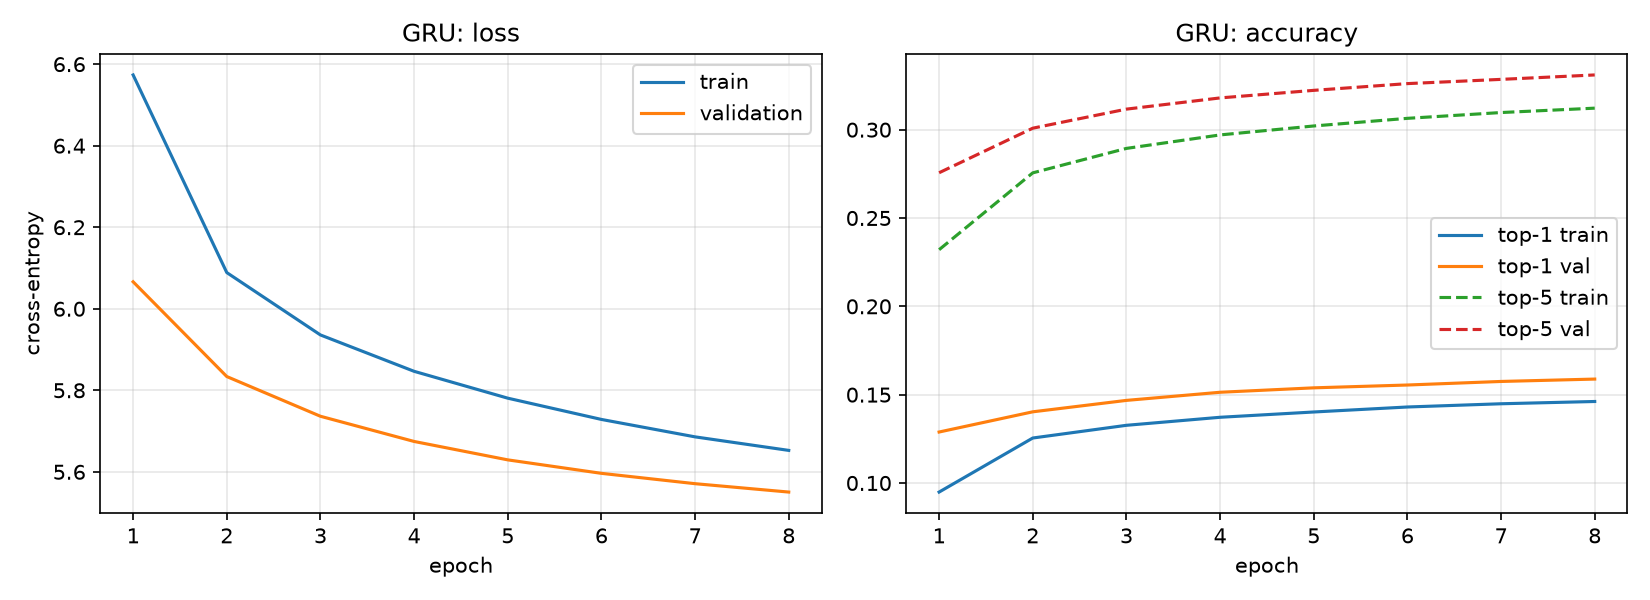

In [4]:
from IPython.display import Image, display

display(Image(filename=str(config.OUTPUTS_DIR / "gru_training_curves.png")))

## 4. Test-set results

In [5]:
pd.Series({k: v for k, v in result.items() if k != "hyperparameters"})

model                gru
parameters       1314960
top1_accuracy     0.1576
top5_accuracy     0.3289
test_loss         5.5665
perplexity        261.52
train_seconds     2032.4
epochs_run             8
best_epoch             8
dtype: object

## 5. Try it

Load the saved model exactly as the web app does.

In [6]:
from src.predict import Predictor

predictor = Predictor.load(config.MODELS_DIR / "gru.keras", config.VOCAB_PATH)

for prompt in ["i want to go to the ", "it is a ", "holmes was ", "what do you "]:
    top5 = predictor.predict_next(prompt, k=5)
    print(f"{prompt!r:<26} ->", ", ".join(f"{s['word']} ({s['probability']:.0%})" for s in top5))

'i want to go to the '     -> end (1%), same (1%), world (1%), new (1%), top (1%)
'it is a '                 -> lot (4%), good (4%), little (3%), great (3%), few (3%)
'holmes was '              -> a (13%), the (4%), in (2%), an (2%), not (1%)
'what do you '             -> have (13%), know (9%), get (4%), do (4%), want (3%)


In [7]:
# Mid-word completion, like a keyboard: the last word is unfinished, so we complete it
for prompt in ["i want to g", "it was a very d"]:
    top5 = predictor.predict_next(prompt, k=5)
    print(f"{prompt!r:<26} ->", ", ".join(s["word"] for s in top5))

'i want to g'              -> get, go, give, grow, grab
'it was a very d'          -> difficult, different, dark, difference, delicious


In [ ]:
# Probability distribution behind the five suggestions (the last box in the sketch)
%matplotlib inline
prompt = "i want to go to the "
top = predictor.predict_next(prompt, k=10)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh([s["word"] for s in top][::-1], [s["probability"] for s in top][::-1], color="#3b4fd8")
ax.set(title=f'Top 10 for "{prompt.strip()}"', xlabel="probability")
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "gru_example_prediction.png")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14540\4141002454.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Next: `05_comparison.ipynb`.